In [1]:
!pip install --upgrade torchao
!pip install -U bitsandbytes>=0.46.1
!pip install trl -q

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

import torch

In [3]:
DATA_DIR = ''

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Data

In [22]:
dataset = pd.read_csv(DATA_DIR + 'text_dataset.csv', encoding='utf-8')
dataset.head()

,id,timestamp,text
0,0,1712998082,А зач
1,1,1712998089,Есть же петрушка
2,2,1712998092,Ну в овсеми
3,3,1712998095,Там не все
4,4,1712998108,Ааа


### Filtering NaNs

In [23]:
dataset['next_text'] = dataset['text'].shift(-1)
dataset['delta_time'] = - dataset['timestamp'] + dataset['timestamp'].shift(-1)
dataset

,id,timestamp,text,next_text,delta_time
0,0,1712998082,А зач,Есть же петрушка,7.0
1,1,1712998089,Есть же петрушка,Ну в овсеми,3.0
2,2,1712998092,Ну в овсеми,Там не все,3.0
3,3,1712998095,Там не все,Ааа,13.0
4,4,1712998108,Ааа,Типа ещё сииимёёён,8.0
...,...,...,...,...,...
151993,151993,1787512789,посмотрим,как же там идет экспорт сообщений,266.0
151994,151994,1787513055,как же там идет экспорт сообщений,полчаса,2.0
151995,151995,1787513057,полчаса,NaN,7.0
151996,151996,1787513064,NaN,мегапон,5.0


In [24]:
dataset.dropna(inplace=True)
dataset.__len__()

128642

### Filtering long reply pairs

<Axes: xlabel='delta_time', ylabel='Count'>

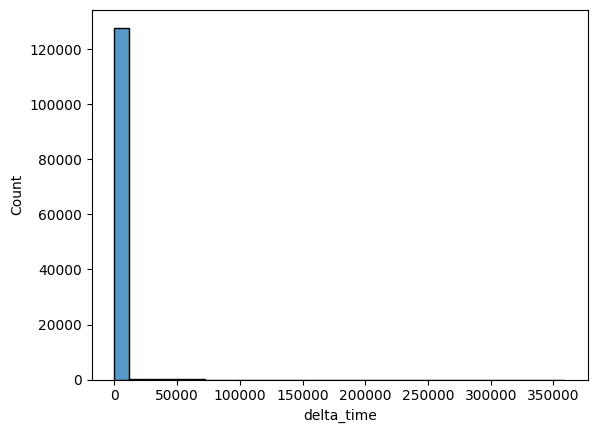

In [25]:
sns.histplot(dataset['delta_time'], bins=30)

<Axes: xlabel='delta_time', ylabel='Count'>

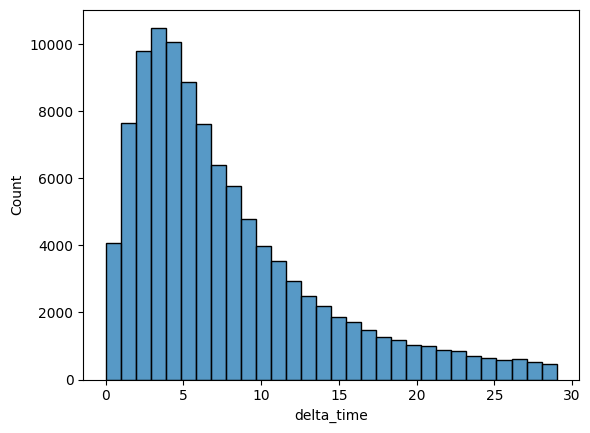

In [26]:
dt = dataset['delta_time']
dataset = dataset[dt < 30]
sns.histplot(dataset['delta_time'], bins=30)

In [27]:
dataset.drop(columns=['delta_time', 'timestamp'], inplace=True)
dataset.__len__()

/tmp/ipykernel_7464/4237814809.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset.drop(columns=['delta_time', 'timestamp'], inplace=True)


105469

### Filtering long texts

/tmp/ipykernel_7464/1722853586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['text_len'] = dataset['text'].str.len() + dataset['next_text'].str.len()


<Axes: xlabel='text_len', ylabel='Count'>

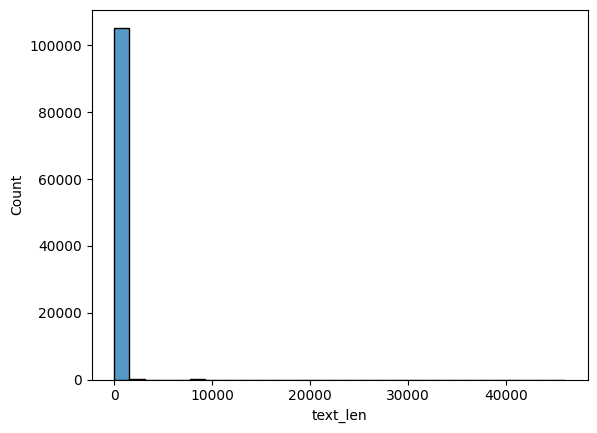

In [28]:
dataset['text_len'] = dataset['text'].str.len() + dataset['next_text'].str.len()

sns.histplot(dataset['text_len'], bins=30)

<Axes: xlabel='text_len', ylabel='Count'>

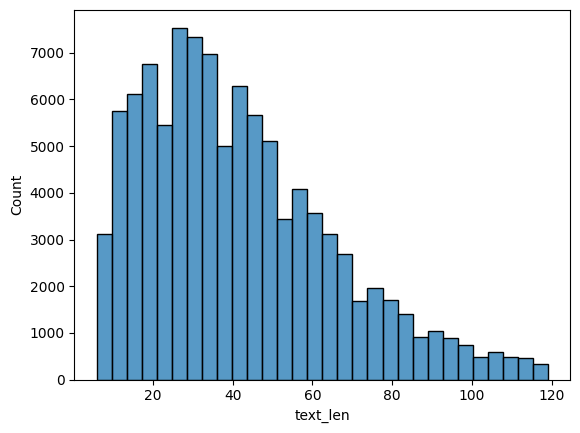

In [29]:
threshold = 4 * 30 # 100 symbols
tl = dataset['text_len']
dataset = dataset[(5 < tl) & (tl < threshold) & (dataset['next_text'].str.len() > 0)]

sns.histplot(dataset['text_len'], bins=30)

In [30]:
dataset.drop(columns=['text_len', 'id'], inplace=True)
dataset

,text,next_text
0,А зач,Есть же петрушка
1,Есть же петрушка,Ну в овсеми
2,Ну в овсеми,Там не все
3,Там не все,Ааа
4,Ааа,Типа ещё сииимёёён
...,...,...
151989,довой довой,ну бота я точно навайбкожу
151990,ну бота я точно навайбкожу,а вот берта можно зафтшить
151991,а вот берта можно зафтшить,ну или гпт
151992,ну или гпт,посмотрим


In [31]:
dataset.reset_index(inplace=True)
dataset.drop(columns=['index'], inplace=True)
dataset

,text,next_text
0,А зач,Есть же петрушка
1,Есть же петрушка,Ну в овсеми
2,Ну в овсеми,Там не все
3,Там не все,Ааа
4,Ааа,Типа ещё сииимёёён
...,...,...
100765,довой довой,ну бота я точно навайбкожу
100766,ну бота я точно навайбкожу,а вот берта можно зафтшить
100767,а вот берта можно зафтшить,ну или гпт
100768,ну или гпт,посмотрим


## LM

### Loading model and processor

In [15]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, TaskType


model_name = 'HuggingFaceTB/SmolLM-135M'

quantization_config = BitsAndBytesConfig(load_in_4bit=True)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map='auto',
    quantization_config=quantization_config
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

In [16]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
)

model.add_adapter(lora_config, adapter_name="my_adapter")

### Dataset format tuning

In [32]:
def preprocess_format(example):
    return {
        "prompt": [{'role': 'user', 'content': example['text']}],
        "completion": [{'role': 'assistant', 'content': example['next_text']}],
    }


preprocess_format(dataset.iloc[0])

{'prompt': [{'role': 'user', 'content': 'А зач'}],
 'completion': [{'role': 'assistant', 'content': 'Есть же петрушка'}]}

In [33]:
dataset = [preprocess_format(dataset.iloc[i]) for i in range(len(dataset))]
dataset[:10]

[{'prompt': [{'role': 'user', 'content': 'А зач'}],
  'completion': [{'role': 'assistant', 'content': 'Есть же петрушка'}]},
 {'prompt': [{'role': 'user', 'content': 'Есть же петрушка'}],
  'completion': [{'role': 'assistant', 'content': 'Ну в овсеми'}]},
 {'prompt': [{'role': 'user', 'content': 'Ну в овсеми'}],
  'completion': [{'role': 'assistant', 'content': 'Там не все'}]},
 {'prompt': [{'role': 'user', 'content': 'Там не все'}],
  'completion': [{'role': 'assistant', 'content': 'Ааа'}]},
 {'prompt': [{'role': 'user', 'content': 'Ааа'}],
  'completion': [{'role': 'assistant', 'content': 'Типа ещё сииимёёён'}]},
 {'prompt': [{'role': 'user', 'content': 'Типа ещё сииимёёён'}],
  'completion': [{'role': 'assistant', 'content': 'Да'}]},
 {'prompt': [{'role': 'user', 'content': 'Да'}],
  'completion': [{'role': 'assistant', 'content': 'И Андрей'}]},
 {'prompt': [{'role': 'user', 'content': 'И Андрей'}],
  'completion': [{'role': 'assistant', 'content': 'Сергеевич'}]},
 {'prompt': [{'rol

In [34]:
dataset = Dataset.from_list(dataset)
dataset

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 100770
})

### SFT

In [35]:
from trl import SFTTrainer
from datasets import Dataset

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
)

Tokenizing train dataset:   0%|          | 0/100770 [00:00<?, ? examples/s]

ValueError: Cannot use chat template functions because tokenizer.chat_template is not set and no template argument was passed! For information about writing templates and setting the tokenizer.chat_template attribute, please see the documentation at https://huggingface.co/docs/transformers/main/en/chat_templating

In [ ]:
trainer.train()